In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cleaning

In [2]:
df = pd.read_csv("Advertising Budget and Sales.csv")
df.head()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
df.tail()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5
199,200,232.1,8.6,8.7,13.4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               200 non-null    int64  
 1   TV Ad Budget ($)         200 non-null    float64
 2   Radio Ad Budget ($)      200 non-null    float64
 3   Newspaper Ad Budget ($)  200 non-null    float64
 4   Sales ($)                200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [5]:
df.isnull().sum()

Unnamed: 0                 0
TV Ad Budget ($)           0
Radio Ad Budget ($)        0
Newspaper Ad Budget ($)    0
Sales ($)                  0
dtype: int64

In [6]:
df = df.drop(columns= ['Unnamed: 0'], axis = 1)
df

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [7]:
df.size

800

In [8]:
df.shape

(200, 4)

In [9]:
df.duplicated().sum()

np.int64(0)

# EDA

In [10]:
df

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [11]:
df.describe()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [12]:
df.skew()

TV Ad Budget ($)          -0.069853
Radio Ad Budget ($)        0.094175
Newspaper Ad Budget ($)    0.894720
Sales ($)                  0.407571
dtype: float64

Some Lower values  are there in TV AD Budget so skew() is negative not suspisious.

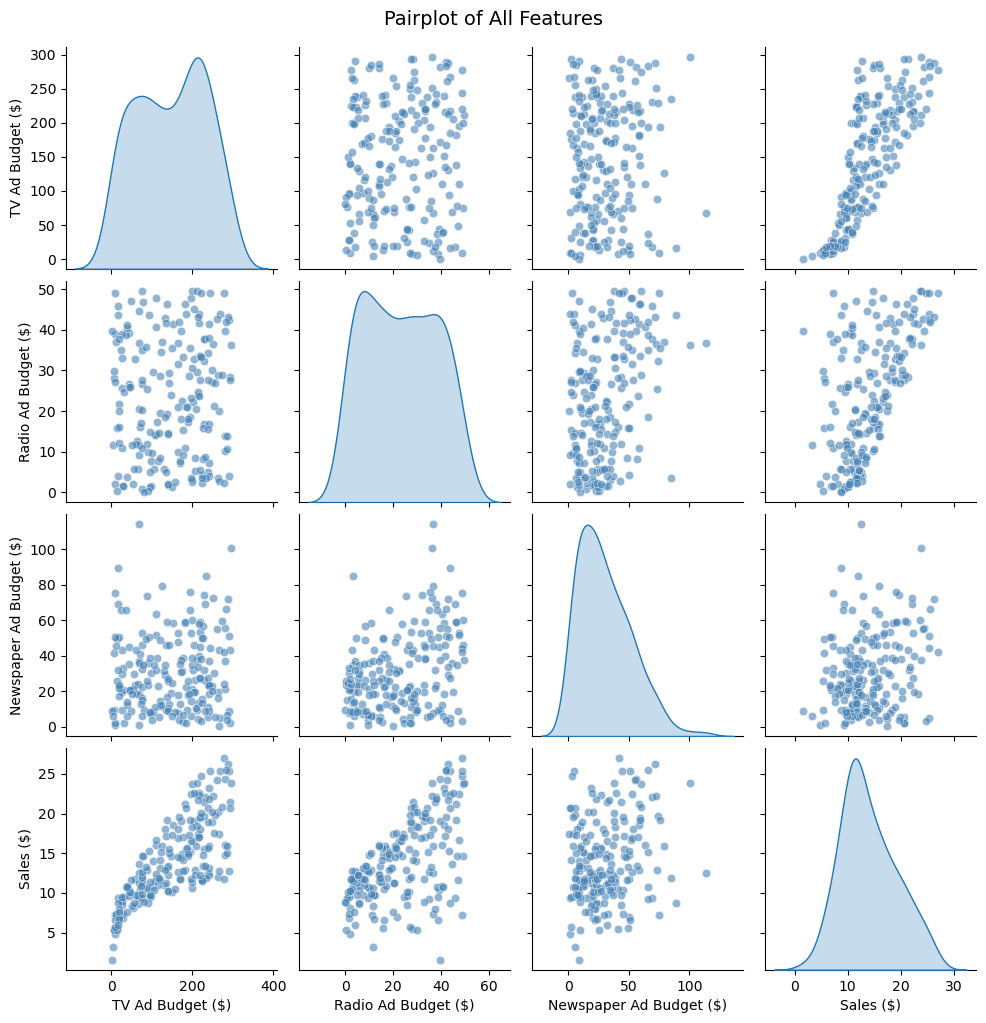

In [13]:
sns.pairplot(df, diag_kind='kde', plot_kws={'alpha': 0.6, 'color': 'steelblue'})
plt.suptitle('Pairplot of All Features', y=1.02, fontsize=14)
plt.show()

1. **TV Ad Budget** is the **strongest predictor** of Sales — clear linear trend
2. **Radio** has **moderate influence** — worth including in the model
3. **Newspaper** shows very **weak correlation** — may not add much predictive power
4. No multicollinearity between features — ideal for Linear Regression
5. **Newspaper** is **right-skewed** nearly going to positive — most budgets are small with few large outliers

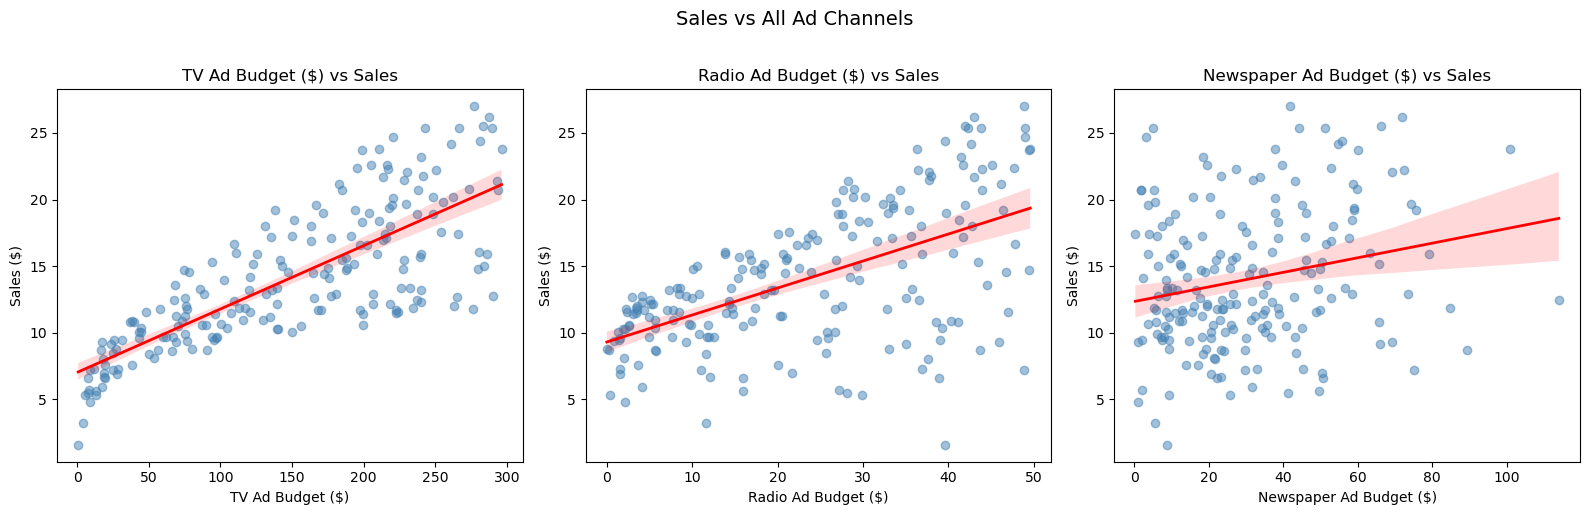

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
channels = ['TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)']
for ax, col in zip(axes, channels):
    sns.regplot(x=col, y='Sales ($)', data=df, ax=ax,
                scatter_kws={'alpha': 0.5, 'color': 'steelblue'},
                line_kws={'color': 'red', 'linewidth': 2})
    ax.set_title(f'{col} vs Sales')
plt.suptitle('Sales vs All Ad Channels', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Before Jump into ML model it's confirm that **Newpaper ad budget** has a bad realtionship with **sales**. For better result without Newspaper Ad budget column Going ahead.

In [15]:
df = df.drop(columns= ['Newspaper Ad Budget ($)'], axis=1)
df

,TV Ad Budget ($),Radio Ad Budget ($),Sales ($)
0,230.1,37.8,22.1
1,44.5,39.3,10.4
2,17.2,45.9,9.3
3,151.5,41.3,18.5
4,180.8,10.8,12.9
...,...,...,...
195,38.2,3.7,7.6
196,94.2,4.9,9.7
197,177.0,9.3,12.8
198,283.6,42.0,25.5


In [16]:
np.corrcoef(df)

array([[ 1.        ,  0.66941967, -0.24664411, ...,  0.99629647,
         0.99994278,  0.99625025],
       [ 0.66941967,  1.        ,  0.55482545, ...,  0.60306385,
         0.66143408,  0.60263633],
       [-0.24664411,  0.55482545,  1.        , ..., -0.32905883,
        -0.25699737, -0.32956478],
       ...,
       [ 0.99629647,  0.60306385, -0.32905883, ...,  1.        ,
         0.99715931,  0.99999986],
       [ 0.99994278,  0.66143408, -0.25699737, ...,  0.99715931,
         1.        ,  0.99711881],
       [ 0.99625025,  0.60263633, -0.32956478, ...,  0.99999986,
         0.99711881,  1.        ]], shape=(200, 200))

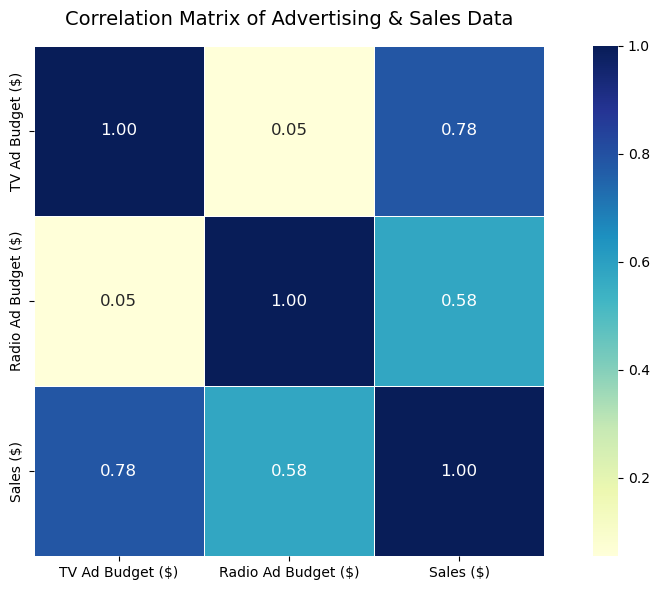

In [17]:
plt.figure(figsize=(10, 6))

corr_matrix = df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,           # Show numbers inside boxes
    fmt='.2f',            # 2 decimal places
    cmap='YlGnBu',      
    linewidths=0.5,
    linecolor='white',
    square=True,
    annot_kws={'size': 12}
)

plt.title('Correlation Matrix of Advertising & Sales Data', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

TV Ad Budget has the strongest correlation with Sales (≈0.78) and with Radio (≈0.58). This shows  how it is appropiate for Linear Regression model. Sales has strong rltnship between TV Ad Budget, Radio Ad Budget, so model can easily find its dependencies for prediction.

# Feature Engineering

In [18]:
from sklearn.model_selection import train_test_split
#Separte Features ans Targeted column
features = ['TV Ad Budget ($)',	'Radio Ad Budget ($)',]

X = df[features]
y = df['Sales ($)']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

# Models

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

model_lin_reg = LinearRegression()
model_lin_reg.fit(X_train,y_train)

y_pred_lin_reg = model_lin_reg.predict(X_test)
print("Model Training is completed.")

compare = pd.DataFrame({
    'Actual Sales ($)': y_test.values.flatten(),  
    'Predicted Sales ($)': y_pred_lin_reg.flatten()
})

print(compare.to_string(index=False))

print("Model Coeficient(slope) is =",model_lin_reg.coef_) 
print('Model intercept is =',model_lin_reg.intercept_) 

Model Training is completed.
 Actual Sales ($)  Predicted Sales ($)
             16.9            16.357473
             22.4            20.862994
             21.4            21.525058
              7.3            10.587198
             24.7            22.224596
             12.6            13.060705
             22.3            21.095644
              8.4             7.476411
             11.5            13.624098
             14.9            15.150194
              9.5             9.127611
              8.7             6.628789
             11.9            14.165311
              5.3             8.970739
             10.3             9.668255
             11.7            12.128217
              5.5             8.712522
             16.6            16.309115
             11.3            10.266842
             18.9            18.890104
             19.7            19.451953
             12.5            13.039256
             10.9            12.411821
             22.2            21.209

### Matrics

In [21]:
MAE  = mean_absolute_error(y_test, y_pred_lin_reg)
MSE  = mean_squared_error(y_test, y_pred_lin_reg)
RMSE = root_mean_squared_error(y_test, y_pred_lin_reg)
R2   = r2_score(y_test,y_pred_lin_reg)
print(f"{MAE:.4f} is the MAE score\n{MSE:.4f} is the MSE score\n{RMSE:.4f} is the RMSE score\n{R2:.4f} is the R2 score")

1.4443 is the MAE score
3.1379 is the MSE score
1.7714 is the RMSE score
0.9006 is the R2 score


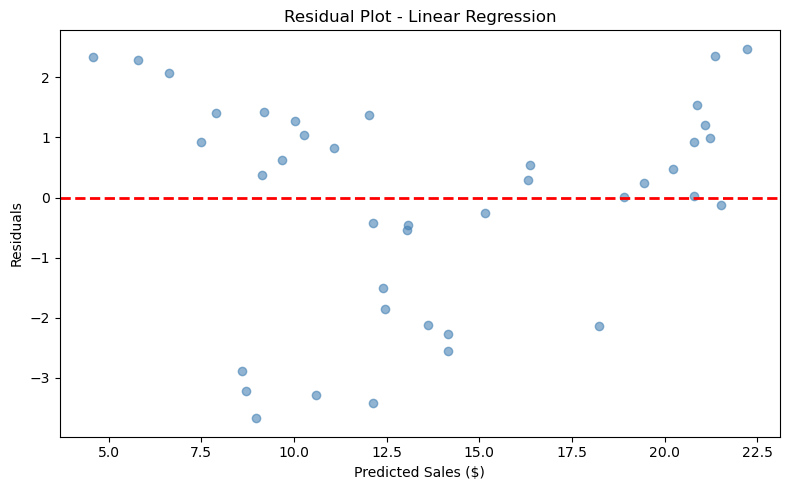

In [22]:
# Residual Plot
residuals = y_test.values.flatten() - y_pred_lin_reg.flatten()

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_lin_reg, residuals, alpha=0.6, color='steelblue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Sales ($)')
plt.ylabel('Residuals')
plt.title('Residual Plot - Linear Regression')
plt.tight_layout()
plt.show()

## Random Forest

In [23]:
from sklearn.ensemble import RandomForestRegressor

model_RF_reg = RandomForestRegressor(n_estimators=100, random_state=42)
model_RF_reg.fit(X_train,y_train)

y_pred_RF_reg = model_RF_reg.predict(X_test)
print("Model Training is completed.")

compare_RF_reg = pd.DataFrame({
    'Actual Sales ($)': y_test.values.flatten(),      # flatten to 1D
    'Predicted Sales ($)': y_pred_RF_reg.flatten()
})

Model Training is completed.


### Matrics 

In [24]:
MAE_RF_reg  = mean_absolute_error(y_test, y_pred_RF_reg)
MSE_RF_reg  = mean_squared_error(y_test, y_pred_RF_reg)
RMSE_RF_reg = root_mean_squared_error(y_test, y_pred_RF_reg)
R2_RF_reg   = r2_score(y_test,y_pred_RF_reg)
print(f"{MAE_RF_reg:.4f} is the MAE score\n{MSE_RF_reg:.4f} is the MSE score\n{RMSE_RF_reg:.4f} is the RMSE score\n{R2_RF_reg:.4f} is the R2 score")

0.5391 is the MAE score
0.4290 is the MSE score
0.6550 is the RMSE score
0.9864 is the R2 score


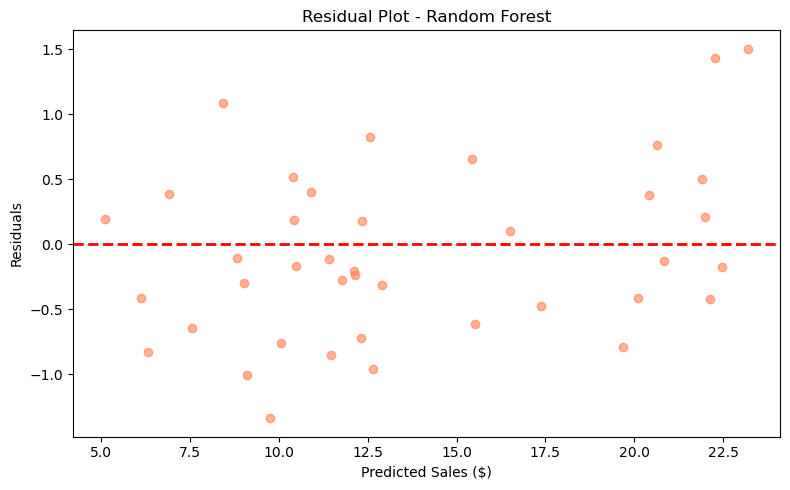

In [25]:
residuals_RF = y_test.values.flatten() - y_pred_RF_reg.flatten()

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_RF_reg, residuals_RF, alpha=0.6, color='coral')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Sales ($)')
plt.ylabel('Residuals')
plt.title('Residual Plot - Random Forest')
plt.tight_layout()
plt.show()

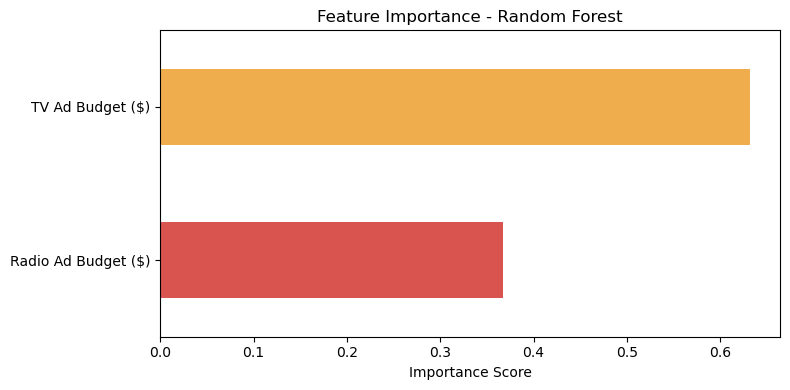

In [26]:
feature_importance = pd.Series(
    model_RF_reg.feature_importances_,
    index=features
).sort_values(ascending=True)

plt.figure(figsize=(8, 4))
feature_importance.plot(kind='barh', color=['#d9534f','#f0ad4e','steelblue'])
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Polynomial Regression

In [33]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

poly = PolynomialFeatures(degree=2, include_bias=False)

model_poly = Pipeline([
    ('polynomial_feature',poly),
    ('linear_reg', LinearRegression())
    ])

model_poly.fit(X_train,y_train)

y_pred_poly_reg = model_poly.predict(X_test)


compare_poly_reg = pd.DataFrame({
    'Actual Sales ($)': y_test.values.flatten(),      # flatten to 1D
    'Predicted Sales ($)': y_pred_poly_reg.flatten()
})
print("Model training Complete.")

Model training Complete.


In [28]:
MAE_poly_reg  = mean_absolute_error(y_test, y_pred_poly_reg)
MSE_poly_reg  = mean_squared_error(y_test, y_pred_poly_reg)
RMSE_poly_reg = root_mean_squared_error(y_test, y_pred_poly_reg)
R2_poly_reg   = r2_score(y_test,y_pred_poly_reg)
print(f"{MAE_poly_reg:.4f} is the MAE score\n{MSE_poly_reg:.4f} is the MSE score\n{RMSE_poly_reg:.4f} is the RMSE score\n{R2_poly_reg:.4f} is the R2 score")

0.4935 is the MAE score
0.3642 is the MSE score
0.6035 is the RMSE score
0.9885 is the R2 score


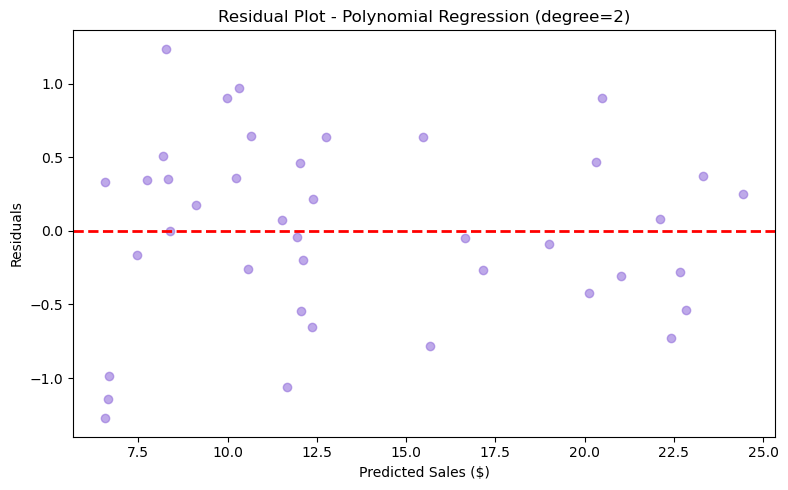

In [29]:
residuals_poly = y_test.values.flatten() - y_pred_poly_reg.flatten()

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_poly_reg, residuals_poly, alpha=0.6, color='mediumpurple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Sales ($)')
plt.ylabel('Residuals')
plt.title('Residual Plot - Polynomial Regression (degree=2)')
plt.tight_layout()
plt.show()

In [30]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Polynomial Regression'],
    'MAE':   [MAE, MAE_RF_reg, MAE_poly_reg],
    'RMSE':  [RMSE, RMSE_RF_reg, RMSE_poly_reg],
    'R²':    [R2, R2_RF_reg, R2_poly_reg]
})
print(results.to_string(index=False))

                Model      MAE     RMSE       R²
    Linear Regression 1.444302 1.771425 0.900583
        Random Forest 0.539125 0.654964 0.986409
Polynomial Regression 0.493482 0.603453 0.988463


# Model COMPARISON

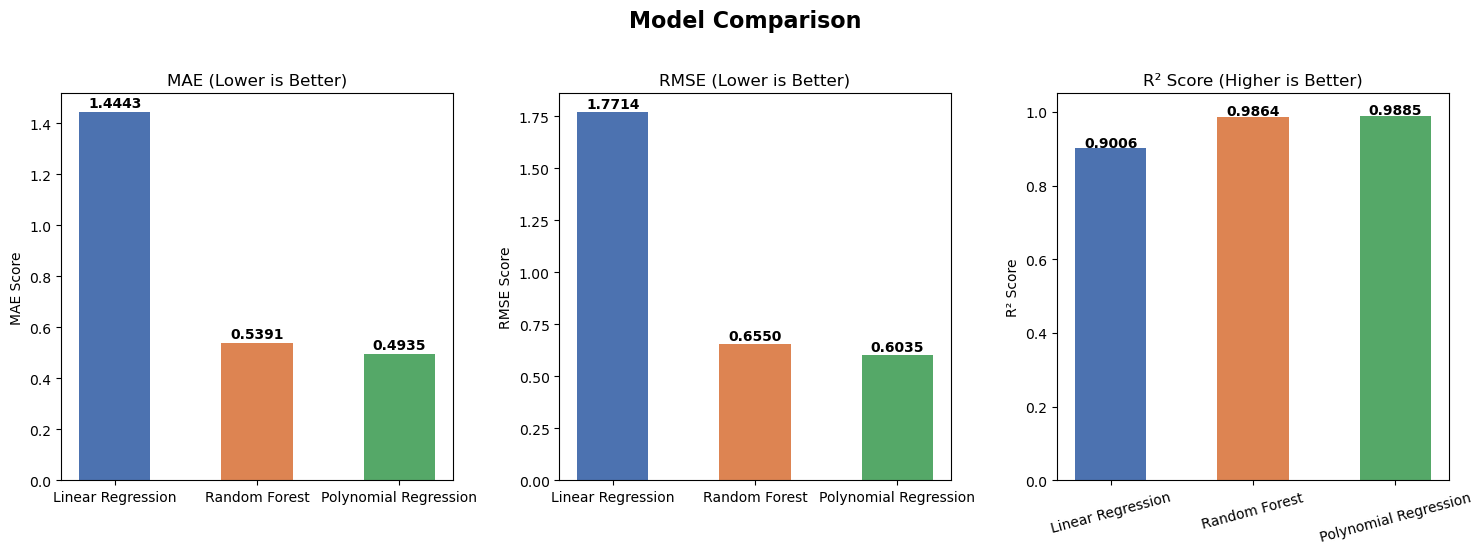

In [31]:
# Model Comparison
models     = ['Linear Regression', 'Random Forest', 'Polynomial Regression']
mae_scores = [MAE,       MAE_RF_reg,  MAE_poly_reg]
rmse_scores= [RMSE,      RMSE_RF_reg, RMSE_poly_reg]
r2_scores  = [R2,        R2_RF_reg,   R2_poly_reg]
colors     = ['#4C72B0', '#DD8452',   '#55A868']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Comparison', fontsize=16, fontweight='bold', y=1.02)



#MAE 
axes[0].bar(models, mae_scores, color=colors, width=0.5)
axes[0].set_title('MAE (Lower is Better)', fontsize=12)
axes[0].set_ylabel('MAE Score')
for i, v in enumerate(mae_scores):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# RMSE
axes[1].bar(models, rmse_scores, color=colors, width=0.5)
axes[1].set_title('RMSE (Lower is Better)', fontsize=12)
axes[1].set_ylabel('RMSE Score')
for i, v in enumerate(rmse_scores):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# R² 
axes[2].bar(models, r2_scores, color=colors, width=0.5)
axes[2].set_title('R² Score (Higher is Better)', fontsize=12)
axes[2].set_ylabel('R² Score')
axes[2].set_ylim(0, 1.05)
for i, v in enumerate(r2_scores):
    axes[2].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

    
plt.tight_layout()
plt.xticks(rotation=15)
plt.show()